In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configurable paths

# Promoter-level chec-seq signal (sumprom) for Human TFs
sumprom_chec_glob = "sumproms/*gz"

# Promoter-level chec-seq signal (sumprom) for yeast TFs (see manuscript)
yeast_tf_sumprom_glob = '../Yeast_Native_TF_outfiles/results/sumproms/*.gz'

## Imports

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import glob
from scipy.stats import zscore
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

## Load data

In [4]:
FOXK1_WT = ["FOXP3","FOXA2","FOXF1","FOXL1","FOXL2","FOXJ2","FOXO3","FOXP1","FOXP2"]
GABPA_WT = ["ELF1","ELF2","ERF1","ELK1","ELK4","ERG","FLI1"]
SOX10_WT = ["SOX15","SOX17","SOX7","SOX11","SOX4","SOX6","SOX30","SOX9","SOX13","SOX5"]
HXD10_WT = ["CDX2","HOXA11","HOXC10","HOXD9","HOXA10","HOXC9","HOXA9","HOXB9","CDX4","HOXC13"]
GATA1_WT = ["GATA3","GATA6","GATA4","GATA2","GATA5"]
BATF3_WT = ["ATF4","FOS","CREB5","ATF1","CREB1","ATF2"]
HEY1_WT = ["MNT","MLXIPL","MLX","MXD4"]
NFAC4_WT = ["NFATC4","NFATC3"]
TF2LY_WT = ["TGIF2LX","TGIF2LY","TGIF1","TGIF2"]
PO3F2_WT = ["POU2F3","POU3F4","POU3F1"]

dbd_fam_dict = {"FOXK1": FOXK1_WT, "GABPA": GABPA_WT, "SOX10": SOX10_WT, "HXD10": HXD10_WT, "GATA1": GATA1_WT, "BATF3": BATF3_WT, "HEY1": HEY1_WT, "NFAC4": NFAC4_WT, "TF2LY": TF2LY_WT, "PO3F2": PO3F2_WT}


yeast_bzips = ["Yap1", "Yap2", "Yap3", "Yap4", "Yap5", "Yap6", "Yap7", "Aca1", "Sko1", "Hac1", "Cst6", "Phd1"]
yeast_gata = ["Gln3", "Gat1", "Dal80", "Gzf3"]
yeast_forkheads = ["Fkh1", "Fkh2", "Hcm1"]

In [5]:
sumprom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

corr_cutoff = 0.895

def filter_reproducible(sumprom_all: pd.DataFrame, cutoff) -> pd.DataFrame:
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]
    
    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]

sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit('_', n=2).str[0]
cols_to_keep = set(sum(dbd_fam_dict.values(), []))
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
sumprom = sumprom.loc[:, sumprom.columns.intersection(cols_to_keep)]
sumprom_z = sumprom.apply(zscore)

In [6]:
native_tf_sumprom_files = glob.glob(yeast_tf_sumprom_glob)
native_tf_sumprom = pd.concat([pd.read_parquet(x) for x in native_tf_sumprom_files], axis=1)
non_transcription_factors = ['Nfi1', 'Itc1', 'Gal11', 'Nhp6A', 'Spt20', 'Nhp6B','Abf2', 'Tog1', 'Siz1', 'Cyc8', "Mss11"]
native_tf_sumprom = native_tf_sumprom.drop(columns=non_transcription_factors)
native_tf_sumprom_z = native_tf_sumprom.apply(zscore)

In [7]:
sumprom_combined_z = pd.concat([sumprom_z, native_tf_sumprom_z], axis=1)

## Plot

In [8]:
sumprom_combined_z_corr = sumprom_combined_z.corr()

In [9]:
def plot_subset_corr_clustered_two_lists(
    sumprom_combined_z,
    samples_list1,
    samples_list2,
    figsize=(4, 4),
):

    seen = set()
    samples = []
    for s in list(samples_list1) + list(samples_list2):
        if s in seen:
            continue
        seen.add(s)
        if s in sumprom_combined_z.index:
            samples.append(s)

    if len(samples) < 2:
        return

    sub = sumprom_combined_z.loc[samples, samples]

    # cluster order using distance = 1 - correlation
    dist = 1 - sub
    Z = linkage(squareform(dist, checks=False), method="average")
    order = leaves_list(Z)
    sub = sub.iloc[order, order]

    fig, ax = plt.subplots(figsize=figsize)

    hm = sns.heatmap(
        sub,
        cmap="coolwarm",
        vmin=0, vmax=1,
        annot=False,
        square=True,
        cbar=False,
        ax=ax
    )

    # colorbar sized to heatmap height
    pos = ax.get_position()
    cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.05, pos.height])
    cbar = plt.colorbar(hm.collections[0], cax=cax)
    cbar.set_label("Pearson's r", fontsize=14, rotation=270, labelpad=15)

    # tick label colors by list membership (after clustering order)
    set1, set2 = set(samples_list1), set(samples_list2)
    tick_order = sub.index.tolist()

    ax.set_xticklabels(tick_order, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(tick_order, rotation=0, fontsize=11)

    for t in ax.get_xticklabels():
        s = t.get_text()
        if s in set1:
            t.set_color("#0B3D91")   # dark blue
        elif s in set2:
            t.set_color("#808080")   # darker grey

    for t in ax.get_yticklabels():
        s = t.get_text()
        if s in set1:
            t.set_color("#0B3D91")
        elif s in set2:
            t.set_color("#808080")

    plt.show()


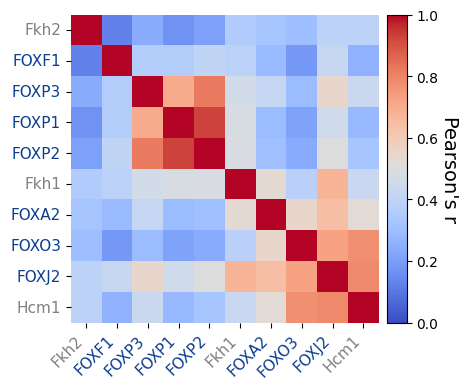

In [10]:
plot_subset_corr_clustered_two_lists(sumprom_combined_z_corr, FOXK1_WT, yeast_forkheads)

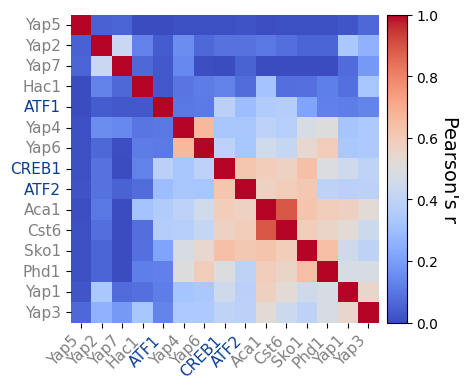

In [11]:
plot_subset_corr_clustered_two_lists(sumprom_combined_z_corr, BATF3_WT, yeast_bzips)

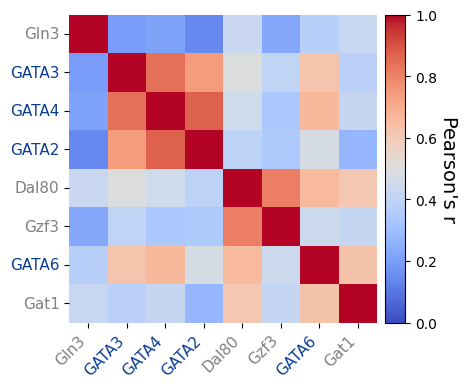

In [12]:
plot_subset_corr_clustered_two_lists(sumprom_combined_z_corr, GATA1_WT, yeast_gata)